<a href="{{ colab_base_laboratorios }}/Laboratorio_06_normal_equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 6 : Ecuación normal

Se puede encontrar una solucion exacta para theta sin necesidad de emplear el gradiente descente de la sesiones pasadas, para ellos se puede encontrar el valor minimo de theta y a partir de alli determinar el valor de theta que minimiza J.

Los pasos para esta minimizacion se dejan como tarea, y pueden ser calculados según lo siguiente:

Si J es la funcion de coste dada por:

\begin{equation}
J(\theta_1,\theta_2,\theta_3, ...,\theta_n )=\frac{1}{2m} \sum_{i = 1}^m (\Theta^{T} X - \hat{y}^{(i)})^2
\end{equation}


Demostrar que:

- $J(\theta_1,\theta_2,\theta_3, ...,\theta_n ) = \frac{1}{2m} (\Theta ^ T X - y^T) (\Theta ^ T X - y^T)^T$

- $J= (\Theta ^T X) (\Theta ^T X)^T - 2(\Theta ^T X)Y  + Y^TY $


- $ \nabla _{\theta} J = \frac{1}{m} (2 X(X^T \Theta) -2XY)$


Para encontrar el valor minimo de \theta,  $\nabla _{\theta} J = 0$,

- $\Theta = (X^T X)^{-1} X^T y$



En este caso,tenemos que:

sea $X \in R^{n\times m}$ ,  $X^T \in R^{m\times n}$

sea $Y \in R^{m \times 1}$,  $Y^T \in R^{1 \times m}$

sea $\Theta \in R^{n \times 1}$, $\Theta^T \in R^{1 \times n}$




Para la demostracion anterior emplee las siguientes propiedades:

- $z^T z= \sum_i z_i^2$
- $a^T b = b^Ta$
- $\nabla _x b^T x = b$
- $\nabla _x  x^T A x = 2Ax$

donde a, b, x son matrices, $\nabla_x$ es la derivada respecto al vector x, y A es una matriz simétrica




1. Para los datos del laboratorio anterior aplicar la ecuacion normal.
2. Tomar el dataset de las casas de Boston y construir un modelo de regresión mutivariada.

```
# Tomar los datos de las casas de boston y hacer una regresion lineal tomando
# el average number of rooms per dwelling.
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

df = pd.DataFrame({"mean_":target, "rm":data[:,5]})

```

## Demostración: Derivación de la ecuación normal

### Paso 1: Forma matricial de J

Partimos de la función de coste:

$$J = \frac{1}{2m}\sum_{i=1}^{m}(\Theta^T X^{(i)} - y^{(i)})^2$$

Usando la propiedad $z^T z = \sum_i z_i^2$, definimos el vector de errores $e = \Theta^T X - Y^T$ (dimensión $1 \times m$), entonces:

$$J = \frac{1}{2m}(\Theta^T X - Y^T)(\Theta^T X - Y^T)^T \quad \checkmark$$

### Paso 2: Expansión del producto

Expandiendo el producto $(a - b)(a - b)^T$ con $a = \Theta^T X$ y $b = Y^T$:

$$J = \frac{1}{2m}\left[(\Theta^T X)(\Theta^T X)^T - (\Theta^T X)Y - Y^T(X^T\Theta) + Y^T Y\right]$$

Usando $a^T b = b^T a$ (escalar), los dos términos cruzados son iguales:

$$J = \frac{1}{2m}\left[(\Theta^T X)(X^T \Theta) - 2(\Theta^T X)Y + Y^T Y\right] \quad \checkmark$$

### Paso 3: Gradiente respecto a Θ

Derivamos cada término respecto a $\Theta$:

- $\nabla_\Theta [(\Theta^T X)(X^T \Theta)] = \nabla_\Theta [\Theta^T (XX^T) \Theta] = 2(XX^T)\Theta$ (usando $\nabla_x x^T A x = 2Ax$ con $A = XX^T$ simétrica)
- $\nabla_\Theta [2(\Theta^T X)Y] = \nabla_\Theta [2(XY)^T \Theta] = 2XY$ (usando $\nabla_x b^T x = b$ con $b = XY$)
- $\nabla_\Theta [Y^T Y] = 0$

Entonces:

$$\nabla_\Theta J = \frac{1}{2m}(2XX^T\Theta - 2XY) = \frac{1}{m}(X(X^T\Theta) - XY) \quad \checkmark$$

### Paso 4: Igualando a cero

$$\nabla_\Theta J = 0 \implies X X^T \Theta = X Y$$

$$\boxed{\Theta = (XX^T)^{-1} X Y}$$

**Nota de convención:** En la notación del curso $X \in \mathbb{R}^{(n+1) \times m}$, la ecuación normal es $\Theta = (XX^T)^{-1}XY$. En la convención estándar donde cada fila es una muestra ($X \in \mathbb{R}^{m \times (n+1)}$), se escribe $\Theta = (X^TX)^{-1}X^Ty$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

## Punto 1: Ecuación normal con datos del laboratorio anterior

Datos: $y = 2.1 x_1 - 3.1 x_2$ (del Lab 05).

Ecuación normal: $\Theta = (XX^T)^{-1} X Y$ donde $X \in \mathbb{R}^{(n+1) \times m}$.

In [2]:
# --- Datos del Lab 05 ---
N = 100
x_1 = 2 * np.random.random(N) - 1   # x1 ∈ [-1, 1]
x_2 = 2 * np.random.random(N) - 1   # x2 ∈ [-1, 1]

theta0_real, theta1_real, theta2_real = 0.0, 2.1, -3.1
y_label = theta0_real + theta1_real * x_1 + theta2_real * x_2  # sin ruido

# Construir matrices: X ∈ R^(n+1, m), Y ∈ R^(m, 1)
X = np.vstack([np.ones(N), x_1, x_2])  # (3, 100)
Y = y_label.reshape(N, 1)               # (100, 1)

print(f"X shape: {X.shape}  →  (n+1, m) = (3, {N})")
print(f"Y shape: {Y.shape}  →  (m, 1)")

# --- Ecuación Normal: Θ = (X Xᵀ)⁻¹ X Y ---
theta_normal = np.linalg.inv(X @ X.T) @ (X @ Y)

print("\n" + "═" * 55)
print("  ECUACIÓN NORMAL — Datos sin ruido")
print("═" * 55)
print(f"  θ₀ = {theta_normal[0, 0]:+.6f}   (real =  0.0)")
print(f"  θ₁ = {theta_normal[1, 0]:+.6f}   (real = +2.1)")
print(f"  θ₂ = {theta_normal[2, 0]:+.6f}   (real = -3.1)")
print("═" * 55)

X shape: (3, 100)  →  (n+1, m) = (3, 100)
Y shape: (100, 1)  →  (m, 1)

═══════════════════════════════════════════════════════
  ECUACIÓN NORMAL — Datos sin ruido
═══════════════════════════════════════════════════════
  θ₀ = +0.000000   (real =  0.0)
  θ₁ = +2.100000   (real = +2.1)
  θ₂ = -3.100000   (real = -3.1)
═══════════════════════════════════════════════════════


Comparación de métodos:
Parámetro          Real   Ec. Normal  Grad. Desc.
------------------------------------------------
θ₀              +0.0000    +0.000000    -0.007695
θ₁              +2.1000    +2.100000    +1.946566
θ₂              -3.1000    -3.100000    -2.412916


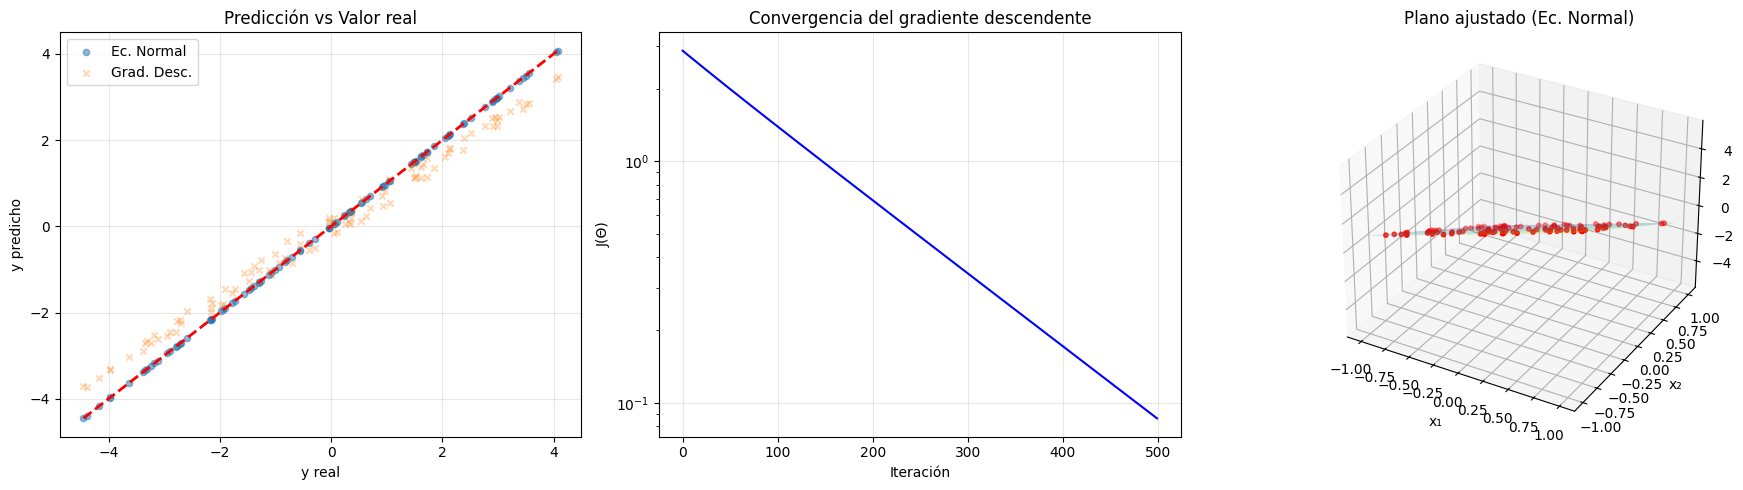


La ecuación normal obtiene la solución exacta en un solo paso,
mientras que el gradiente descendente la aproxima iterativamente.


In [3]:
# --- Comparación: Ecuación normal vs Gradiente descendente ---

# Gradiente descendente (del Lab 05)
def model(theta, X):
    return theta.T @ X

def costo(h, Y, m):
    return (1 / (2 * m)) * np.sum((h - Y.T) ** 2)

def gradient_descent_multi(X, Y, lr=0.01, n_iter=500):
    n_features = X.shape[0]
    m = X.shape[1]
    theta = np.random.RandomState(42).random(n_features).reshape(n_features, 1)
    J_hist = []
    for _ in range(n_iter):
        h = model(theta, X)
        J_hist.append(costo(h, Y, m))
        grad = (1 / m) * (X @ (h - Y.T).T)
        theta = theta - lr * grad
    return theta, J_hist

theta_gd, J_hist = gradient_descent_multi(X, Y, lr=0.01, n_iter=500)

print("Comparación de métodos:")
print(f"{'Parámetro':<12} {'Real':>10} {'Ec. Normal':>12} {'Grad. Desc.':>12}")
print("-" * 48)
for i, name in enumerate(["θ₀", "θ₁", "θ₂"]):
    real = [0.0, 2.1, -3.1][i]
    print(f"{name:<12} {real:>+10.4f} {theta_normal[i, 0]:>+12.6f} {theta_gd[i, 0]:>+12.6f}")

# Verificar predicciones
y_pred_normal = (theta_normal.T @ X).ravel()
y_pred_gd = (theta_gd.T @ X).ravel()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicción vs real
axes[0].scatter(y_label, y_pred_normal, alpha=0.5, s=20, label="Ec. Normal")
axes[0].scatter(y_label, y_pred_gd, alpha=0.3, s=20, marker="x", label="Grad. Desc.")
lims = [y_label.min(), y_label.max()]
axes[0].plot(lims, lims, "r--", linewidth=2)
axes[0].set_xlabel("y real"); axes[0].set_ylabel("y predicho")
axes[0].set_title("Predicción vs Valor real")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Convergencia del GD
axes[1].plot(J_hist, "b-", linewidth=1.5)
axes[1].set_xlabel("Iteración"); axes[1].set_ylabel("J(Θ)")
axes[1].set_title("Convergencia del gradiente descendente")
axes[1].set_yscale("log"); axes[1].grid(True, alpha=0.3)

# Plano ajustado 3D
ax3 = axes[2]
ax3.remove()
ax3 = fig.add_subplot(133, projection="3d")
x1_g = np.linspace(-1, 1, 30)
x2_g = np.linspace(-1, 1, 30)
X1m, X2m = np.meshgrid(x1_g, x2_g)
Y_plane = theta_normal[0, 0] + theta_normal[1, 0] * X1m + theta_normal[2, 0] * X2m
ax3.plot_surface(X1m, X2m, Y_plane, alpha=0.3, cmap="viridis")
ax3.scatter(x_1, x_2, y_label, color="red", s=10)
ax3.set_xlabel("x₁"); ax3.set_ylabel("x₂"); ax3.set_zlabel("y")
ax3.set_title("Plano ajustado (Ec. Normal)")

plt.tight_layout()
plt.show()

print("\nLa ecuación normal obtiene la solución exacta en un solo paso,")
print("mientras que el gradiente descendente la aproxima iterativamente.")

In [4]:
# --- Ecuación normal con datos ruidosos ---
y_noisy = theta1_real * x_1 + theta2_real * x_2 + 0.2 * (2 * np.random.random(N) - 1)
Y_noisy = y_noisy.reshape(N, 1)

theta_noisy = np.linalg.inv(X @ X.T) @ (X @ Y_noisy)

print("Ecuación normal con ruido:")
print(f"  θ₀ = {theta_noisy[0, 0]:+.6f}   (real =  0.0)")
print(f"  θ₁ = {theta_noisy[1, 0]:+.6f}   (real = +2.1)")
print(f"  θ₂ = {theta_noisy[2, 0]:+.6f}   (real = -3.1)")

# Coste final
y_pred_noisy = (theta_noisy.T @ X).ravel()
J_noisy = (1 / (2 * N)) * np.sum((y_pred_noisy - y_noisy) ** 2)
print(f"  J final = {J_noisy:.6f}")
print("\nCon ruido los parámetros se aproximan pero J > 0 (ajuste imperfecto).")

Ecuación normal con ruido:
  θ₀ = +0.006410   (real =  0.0)
  θ₁ = +2.091580   (real = +2.1)
  θ₂ = -3.129593   (real = -3.1)
  J final = 0.006661

Con ruido los parámetros se aproximan pero J > 0 (ajuste imperfecto).


## Punto 2: Dataset de Boston — Regresión multivariada con ecuación normal

Usamos el dataset de casas de Boston. Primero, regresión univariada con `rm` (average number of rooms), luego multivariada con todas las características.

In [5]:
# --- Cargar dataset de Boston ---
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Nombres de las características
feature_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
                 "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

df_boston = pd.DataFrame(data, columns=feature_names)
df_boston["MEDV"] = target

print(f"Dataset de Boston: {df_boston.shape[0]} muestras, {df_boston.shape[1] - 1} características")
print(f"\nCaracterísticas: {feature_names}")
print(f"\nVariable objetivo: MEDV (Median value of homes in $1000's)")
df_boston.describe().round(2)

Dataset de Boston: 506 muestras, 13 características

Características: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Variable objetivo: MEDV (Median value of homes in $1000's)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


### 2a. Regresión univariada: MEDV vs RM (average rooms per dwelling)

Regresión univariada: MEDV = θ₀ + θ₁ · RM
  θ₀ = -34.6706
  θ₁ = 9.1021

sklearn: θ₀ = -34.6706, θ₁ = 9.1021

J = 21.8003
R² = 0.4835


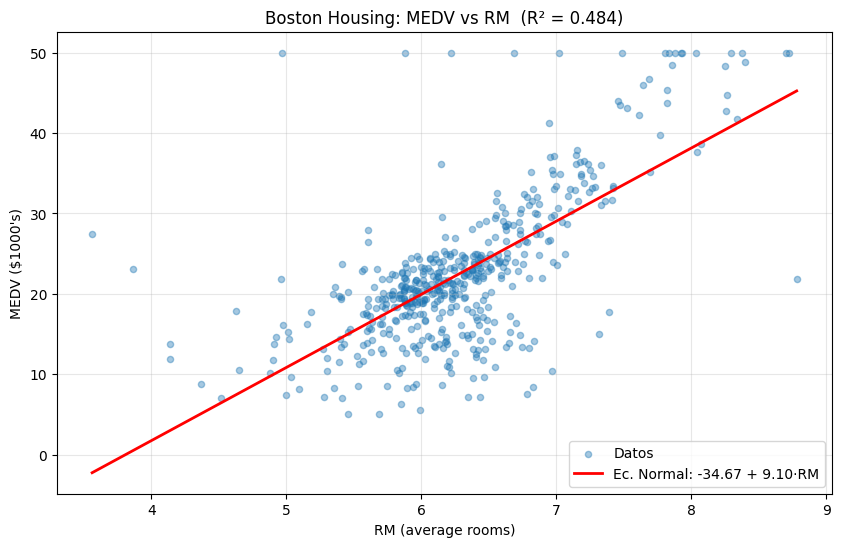

In [6]:
# --- Regresión univariada: MEDV ~ RM ---
rm = df_boston["RM"].values
medv = df_boston["MEDV"].values
m_boston = len(medv)

# Matriz de diseño: X_uni ∈ R^(2, m) — [1; rm]
X_uni = np.vstack([np.ones(m_boston), rm])  # (2, 506)
Y_boston = medv.reshape(m_boston, 1)          # (506, 1)

# Ecuación normal
theta_uni = np.linalg.inv(X_uni @ X_uni.T) @ (X_uni @ Y_boston)

print("Regresión univariada: MEDV = θ₀ + θ₁ · RM")
print(f"  θ₀ = {theta_uni[0, 0]:.4f}")
print(f"  θ₁ = {theta_uni[1, 0]:.4f}")

# Comparar con sklearn
from sklearn.linear_model import LinearRegression
sk_uni = LinearRegression().fit(rm.reshape(-1, 1), medv)
print(f"\nsklearn: θ₀ = {sk_uni.intercept_:.4f}, θ₁ = {sk_uni.coef_[0]:.4f}")

# Predicciones y métricas
y_pred_uni = (theta_uni.T @ X_uni).ravel()
J_uni = (1 / (2 * m_boston)) * np.sum((y_pred_uni - medv) ** 2)
r2_uni = 1 - np.sum((medv - y_pred_uni)**2) / np.sum((medv - np.mean(medv))**2)
print(f"\nJ = {J_uni:.4f}")
print(f"R² = {r2_uni:.4f}")

# Gráfica
rm_sorted = np.sort(rm)
y_line = theta_uni[0, 0] + theta_uni[1, 0] * rm_sorted

plt.figure(figsize=(10, 6))
plt.scatter(rm, medv, alpha=0.4, s=20, label="Datos")
plt.plot(rm_sorted, y_line, "r-", linewidth=2,
         label=f"Ec. Normal: {theta_uni[0, 0]:.2f} + {theta_uni[1, 0]:.2f}·RM")
plt.xlabel("RM (average rooms)")
plt.ylabel("MEDV ($1000's)")
plt.title(f"Boston Housing: MEDV vs RM  (R² = {r2_uni:.3f})")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

### 2b. Regresión multivariada: MEDV ~ todas las características

Usamos las 13 características para construir un modelo completo con ecuación normal.

In [7]:
# --- Regresión multivariada: MEDV ~ todas las características ---

# Matriz de diseño: X_multi ∈ R^(14, 506) — [1; x1; x2; ...; x13]
X_multi = np.vstack([np.ones(m_boston), data.T])  # (14, 506)
print(f"X_multi shape: {X_multi.shape}  →  (n+1, m) = (14, {m_boston})")

# Ecuación normal: Θ = (X Xᵀ)⁻¹ X Y
theta_multi = np.linalg.inv(X_multi @ X_multi.T) @ (X_multi @ Y_boston)

print("\nParámetros encontrados:")
print(f"  {'Parámetro':<12} {'Nombre':<12} {'Valor':>10}")
print("  " + "-" * 36)
print(f"  {'θ₀':<12} {'intercept':<12} {theta_multi[0, 0]:>+10.4f}")
for i, name in enumerate(feature_names):
    print(f"  {'θ' + str(i+1):<12} {name:<12} {theta_multi[i+1, 0]:>+10.4f}")

# Predicciones y métricas
y_pred_multi = (theta_multi.T @ X_multi).ravel()
J_multi = (1 / (2 * m_boston)) * np.sum((y_pred_multi - medv) ** 2)
r2_multi = 1 - np.sum((medv - y_pred_multi)**2) / np.sum((medv - np.mean(medv))**2)

# Comparar con sklearn
sk_multi = LinearRegression().fit(data, medv)
y_pred_sk = sk_multi.predict(data)
r2_sk = 1 - np.sum((medv - y_pred_sk)**2) / np.sum((medv - np.mean(medv))**2)

print(f"\n{'Métrica':<20} {'Ec. Normal':>12} {'sklearn':>12}")
print("-" * 46)
print(f"{'J (coste)':<20} {J_multi:>12.4f} {'—':>12}")
print(f"{'R²':<20} {r2_multi:>12.4f} {r2_sk:>12.4f}")
print(f"{'Max |Δcoef|':<20} {np.max(np.abs(theta_multi[1:, 0] - sk_multi.coef_)):>12.2e} {'—':>12}")

X_multi shape: (14, 506)  →  (n+1, m) = (14, 506)

Parámetros encontrados:
  Parámetro    Nombre            Valor
  ------------------------------------
  θ₀           intercept      +36.4595
  θ1           CRIM            -0.1080
  θ2           ZN              +0.0464
  θ3           INDUS           +0.0206
  θ4           CHAS            +2.6867
  θ5           NOX            -17.7666
  θ6           RM              +3.8099
  θ7           AGE             +0.0007
  θ8           DIS             -1.4756
  θ9           RAD             +0.3060
  θ10          TAX             -0.0123
  θ11          PTRATIO         -0.9527
  θ12          B               +0.0093
  θ13          LSTAT           -0.5248

Métrica                Ec. Normal      sklearn
----------------------------------------------
J (coste)                 10.9474            —
R²                         0.7406       0.7406
Max |Δcoef|              3.15e-12            —


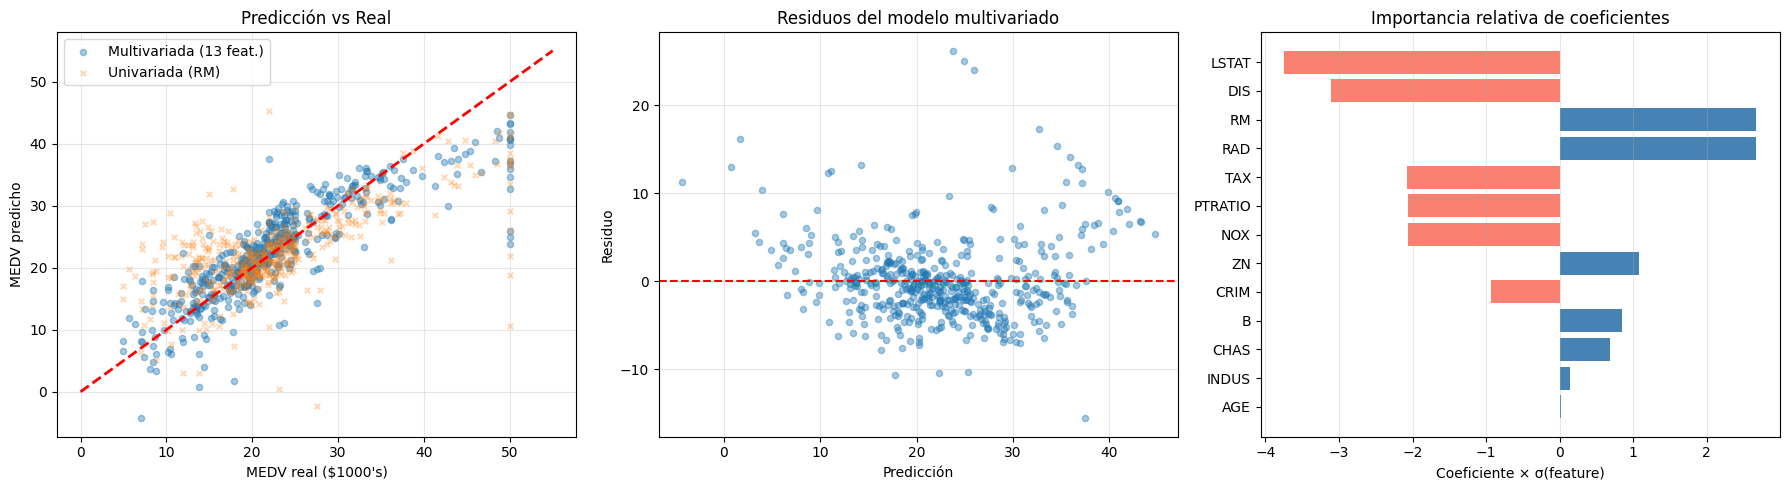


Resumen:
  Regresión univariada (RM):           R² = 0.4835
  Regresión multivariada (13 feat.):   R² = 0.7406
  Mejora al usar todas las features:  ΔR² = 0.2571

  LSTAT (% lower status) y RM (rooms) son las más influyentes.


In [8]:
# --- Visualización del modelo multivariado ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicción vs real
axes[0].scatter(medv, y_pred_multi, alpha=0.4, s=20, label="Multivariada (13 feat.)")
axes[0].scatter(medv, y_pred_uni, alpha=0.3, s=15, marker="x", label="Univariada (RM)")
lims = [0, 55]
axes[0].plot(lims, lims, "r--", linewidth=2)
axes[0].set_xlabel("MEDV real ($1000's)")
axes[0].set_ylabel("MEDV predicho")
axes[0].set_title("Predicción vs Real")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Residuos del modelo multivariado
residuos = medv - y_pred_multi
axes[1].scatter(y_pred_multi, residuos, alpha=0.4, s=20)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicción"); axes[1].set_ylabel("Residuo")
axes[1].set_title("Residuos del modelo multivariado")
axes[1].grid(True, alpha=0.3)

# Importancia de coeficientes (normalizados)
# Normalizar por la desviación estándar de cada feature para comparar
std_features = data.std(axis=0)
coef_norm = theta_multi[1:, 0] * std_features
sorted_idx = np.argsort(np.abs(coef_norm))
axes[2].barh(range(13), coef_norm[sorted_idx], color=["steelblue" if c > 0 else "salmon" for c in coef_norm[sorted_idx]])
axes[2].set_yticks(range(13))
axes[2].set_yticklabels([feature_names[i] for i in sorted_idx])
axes[2].set_xlabel("Coeficiente × σ(feature)")
axes[2].set_title("Importancia relativa de coeficientes")
axes[2].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print(f"\nResumen:")
print(f"  Regresión univariada (RM):           R² = {r2_uni:.4f}")
print(f"  Regresión multivariada (13 feat.):   R² = {r2_multi:.4f}")
print(f"  Mejora al usar todas las features:  ΔR² = {r2_multi - r2_uni:.4f}")
print(f"\n  LSTAT (% lower status) y RM (rooms) son las más influyentes.")

# Intepretación Probabilistica.

Supongamos que tenemos una caracteristica $x_i$ con m valores de entrenamiento, si asumimos que cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$, cada $y_i$ podrá tener el siguiente valor:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo ademas que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Escribiendo, lo anterior en terminos de la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ parametrizado por $\theta$ obtenemos que:


\begin{equation}
p_i(y^{i}|x^{i};\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}



Si ausmimos independencia estadística de cada $\epsilon^{(i)}$, la probabilidad $L(\theta)$ asociada a toda la distribución de puntos viene dada por:

\begin{equation}
\cal{L}(\theta) = p(\vec{y}|X;\theta)=\prod_{i=1}^{n} p_i(y^{i}|x^{i};\theta)
\end{equation}



\begin{equation}
\cal{L}(\theta) =\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}

para tener la mejor estimación posible de los valores que se deben elegir de  $\theta$, se escogeran los parámetros que generan la mayor probabilidad de ocurrencia según las observaciones, es decir, aquellos valores para el cual $L(\theta)$ es máximo, si aplicamos el logaritmo natural antes de máximar tenemos que:

\begin{equation}
\ln \cal{L}(\theta) = \cal{l}(\theta) = \ln \left[\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}} \right]
\end{equation}


Después de un par de pasos se puede encontrar que:

\begin{equation}
\cal{l}(\theta) = n\ln \frac{1}{\sqrt{2\pi\sigma}} - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^{i}-\Theta^T X^{i})^2
\end{equation},

maximar $\cal{l(\theta)}$ equivale a encontrar donde  $\nabla_{\theta} \cal{l(\theta)} = 0$. Lo anterior muestra por que la elección de minimos cuadrados puede ser una buena eleccción para el analisis de los datos.

# Intepretación Probabilistica de la regularizacion.

Supongamos adicionalmente que el vector de parámetros $\theta$ también es aleatorio, es decir es un vector de variables aleatorias, con lo cual incluiríamos entonces toda la aleatoriedad posible que pueden tener los mecanismos del sistema que estamos estudiando. La distribución de $\theta$ es también una normal en función de la norma de $\theta$:

\begin{equation}
p(\theta)=\frac{1}{\sqrt{2\pi\tau}} e^{-\frac{ \left| \theta \right|^2 }{2 \tau ^2}}
\end{equation}

Tenemos como en el caso anterior que tanto las caracteristicas x como y son variables aleatorias y que si tenemos una caracteristica $x_i$ cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo de nuevo que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Ahora por la ley de Bayes podemos expresar la probabilidad de $\theta$ dados los datos $X$ y $y$ y preguntarmos por los valores de $\theta$ que maximizan la probabilidad.

\begin{equation}
p(\theta | X, y) = \frac{p(X,y | \theta) p(\theta)} {p(X,Y)}
 = \frac{P(y | X, \theta) p(\theta)}{p(Y|X)}
\end{equation}
donde asumimos la independencia de $X$ de $\theta$ con la propiedad $p(X|\theta)=p(X)$

El máximo de la probabilidad se obtiene maximizando el nominador pues el denominador no depende de $\theta$. Estos parámetros que se obtienen por este método se denominan Maximum a Posteriori MAP. Note que la expresión es la misma anterior excepto que ahora está multiplicada por la probabilidad de $\theta$

Igualmente tenemos la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ y un $\theta$ dados por:


\begin{equation}
p_i(y^{i}|x^{i},\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}
